# 第47课 · 搭出 Whisper 的耳朵——log-Mel 流水线：STFT → 功率谱 → Mel → log 一气呵成

**目标**：把 Whisper 的前端真正搭出来：STFT → 功率谱 → Mel → log，最后得到 `(n_frames, n_mels)`。

> **管线灵魂**：每一步都画一张 **shape 变化表**（帧×频 → 帧×mel），你就不会在维度里迷路。这是 L70 输入特征的直接前身。

🔗 Aurora 连接：`aurora.audio.mel.mel_spectrogram()` — Month 2 关键词识别分类器的输入特征。

← **上一课**　[L46 · Mel 频率尺度](L46_mel.ipynb)

> 上节课学习了 **Mel 频率尺度**：人耳对数感知，mel = 2595·log₁₀(1+f/700)，三角滤波器。  
> 本课将把 **log-Mel 流水线** 从公式真正落到代码里。

## 学习目标

1. 能从功率谱手推 Mel 能量矩阵：理解 `power @ fb.T` 的 shape 流向
2. 能解释 eps 的数值意义：为何 log(1e-8) ≈ -18.4 是可接受的下界
3. 能独立实现 `log_mel_spectrogram` 并与 `aurora.audio.mel` 参考输出对齐至 1e-6
4. 能解释 Mel 尺度的非线性分布：为何前 40 个 bin 覆盖 0–1730 Hz，后 40 个 bin 覆盖 1730–8000 Hz


## 本课剧情：为什么语音识别用 log-Mel，而不是原始波形？

你跟 Siri 说"播放音乐"，它识别的不是麦克风录到的原始 PCM 数字。原始波形包含 16000 个采样点/秒，但 99% 是相位噪声——对识别毫无帮助。

语音识别的真正输入是 **log-Mel 频谱**：先把信号压缩到人耳感知频率，再用 log 压缩响度，把 80 维向量/帧送进神经网络。这是 Whisper、Wav2Vec2、所有主流 ASR 模型的标准输入格式。

**完整 5 步流水线**：

```
x          (T,)            ← 原始音频
↓ STFT
S          (n_frames, n_fft//2+1)   ← 复数频谱
↓ |·|²
power      (n_frames, n_fft//2+1)   ← 功率谱
↓ @ mel_filterbank.T
mel_energy (n_frames, n_mels)       ← Mel 能量
↓ log(·+ε)
log_mel    (n_frames, n_mels)       ← 最终特征 ✓
```

**核心公式**（一行）：
$$\text{log\_mel} = \log\!\left(\text{power} \cdot F^T + \varepsilon\right)$$

- `F`：Mel 滤波器组矩阵，shape `(n_mels, n_fft//2+1)`
- `ε = 1e-8`：防止 log(0) = −∞，把最小值钳在 `log(1e-8) ≈ -18`

本节任务：实现 `log_mel_spectrogram(x, sr, n_mels=80, win_len=1024, hop=256)`，与 `aurora.audio.mel.mel_spectrogram` 输出误差 < 1e-6。

## 开课前 2 分钟复习：矩阵乘法就是滤波

- `power @ fb.T` 是把每帧功率谱投影到 Mel 三角滤波器上
- 这里的 `fb` 来自 L46 的三角滤波器组
- 记住 shape：`power (T,F)` × `fb.T (F,M)` → `mel_energy (T,M)`

L21 里你已经见过同一件事的矩阵版本；现在只是在 Audio DSP 里重新出现。

### 🔍 矩阵乘法 `power @ fb.T` 为什么不能反过来？

**很多人的第一反应**："滤波 = 用滤波器乘以功率谱"，那为什么不直接 `fb @ power`？

答案在 **shape 不兼容**，但背后的**算法含义**更重要。

#### 形状角度

- `fb` 形状 `(n_mels, n_fft//2+1)` ——每**行**是一个 Mel 滤波器
- `power` 形状 `(n_frames, n_fft//2+1)` ——每**行**是一帧的功率谱
- `fb @ power` = `(n_mels, n_fft//2+1) @ (n_frames, n_fft//2+1)` → **不能乘**（维度不匹配）
- `power @ fb.T` = `(n_frames, n_fft//2+1) @ (n_fft//2+1, n_mels)` → ✓ 得到 `(n_frames, n_mels)`

#### 算法角度（用小例子）

假设只有 1 帧、5 个 FFT bin、2 个 Mel 滤波器：

```
power（一帧）= [p₁, p₂, p₃, p₄, p₅]  形状 (1, 5)
fb（2个滤波器）= [[f₁₁, f₁₂, f₁₃, f₁₄, f₁₅],    形状 (2, 5)
                [f₂₁, f₂₂, f₂₃, f₂₄, f₂₅]]
```

**用 `power @ fb.T` 计算**：

```
power @ fb.T = [p₁, p₂, p₃, p₄, p₅] @ [[f₁₁, f₂₁],
                                       [f₁₂, f₂₂],
                                       [f₁₃, f₂₃],
                                       [f₁₄, f₂₄],
                                       [f₁₅, f₂₅]]

= [p₁·f₁₁ + p₂·f₁₂ + p₃·f₁₃ + p₄·f₁₄ + p₅·f₁₅,
   p₁·f₂₁ + p₂·f₂₂ + p₃·f₂₃ + p₄·f₂₄ + p₅·f₂₅]

= [第1个Mel滤波器与这帧的内积,
   第2个Mel滤波器与这帧的内积]
```

**物理含义**：`power @ fb.T` 的每个数字 = "这一帧的功率谱向量" · "某个 Mel 滤波器向量" = **投影**。你在问"这帧的能量在第 m 个频率通道上有多少"，这正是滤波的定义。

**如果硬用 `fb @ power`**（假设能乘）：

```
fb @ power = [[f₁₁, f₁₂, ...], × [p₁, p₂, ..., ...帧1],
              [f₂₁, f₂₂, ...]]   [p₁, p₂, ..., ...帧2]
                                 [...]

最后一行结果： f₂₁ · [帧1的p₁] + f₂₂ · [帧1的p₂] + ...
```

这混淆了"滤波器"和"帧"的角色：你在用滤波器的每个数字去乘以不同帧的数据，这没有物理意义。

所以 **`power @ fb.T` 是唯一正确的顺序**。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from aurora.audio.io import sine, chirp

sr = 16000
# 生成测试信号：2 秒 chirp（200 Hz → 4000 Hz）
x = chirp(200, 4000, duration=2.0, sample_rate=sr)
print(f"x.shape = {x.shape}, sr = {sr}")

x.shape = (32000,), sr = 16000


## 1. 什么是 log-Mel？

核心公式只有一行：

```
log_mel = log( power_spectrum @ mel_filterbank.T + eps )
```

其中：
- `mel_filterbank` shape `(n_mels, n_fft//2+1)`：每行是一个三角带通滤波器的权重向量
- `power_spectrum` shape `(n_frames, n_fft//2+1)`：每帧的功率谱（|STFT|²）
- `eps = 1e-8`：防止 log(0)，数值保护
- 结果 shape `(n_frames, n_mels)`

**log 压缩的意义**：人耳对响度的感知是对数的（60 dB 和 61 dB 的差异远小于 0 dB 和 1 dB）。不做 log 的 mel 能量跨越多个数量级，神经网络难以学习；log 压缩后数值分布更均匀，梯度更稳定。

---

### 第一步：理解 Mel 尺度公式

**Mel 尺度定义**（1937 年 Stanley Smith Stevens 实验测量）：

$$\text{mel} = 2595 \cdot \log_{10}\left(1 + \frac{f}{700}\right)$$

**这个公式是怎么来的？**

1. **人耳听觉非线性**：用训练过的听者做"音高匹配"实验——给一个参考频率（如 1000 Hz），再给一个测试频率，让听者调整它的强度，直到听起来"音高相同"。结果发现：
   - 1000 Hz 定义为 1000 Mel（人为标准点）
   - 2000 Hz 听起来的"高度"约是 1300 Mel（不是 2000 Mel！）
   - 200 Hz 听起来的"高度"约是 300 Mel
   
   这意味着高频"被压缩"了：音高感知上，100→200 Hz 的跳跃感觉远大于 4000→4100 Hz。

2. **对数的诞生**：实验数据用 $\log_{10}(1 + f/700)$ 来拟合，然后缩放系数 2595 使得 1000 Hz = 1000 Mel。这**不是推导出来的**，而是**实验测量+拟合的结果**。

   - 700 Hz：人耳的一个特征频率（尺度尺度）
   - 2595：为了让 mel(1000 Hz) = 1000

**你需要记住**：Mel 尺度 = 对数尺度 = 人耳音高感知尺度。在 Mel 刻度上均匀分布的点，映射回 Hz 时自动变成非均匀的（低频密集，高频稀疏）。

---

### 第二步：为什么是三角形滤波器，而不是矩形？

**是人耳的两个物理事实决定的**：

#### 事实 1：临界带宽与掩蔽效应（生活化例子）

想象你在嘈杂的咖啡厅里。朋友在你耳边说话（2000 Hz），同时背景音乐有一个噪声（2050 Hz）。你能听清朋友的话吗？

**答案通常是"听不清"**。虽然 2000 Hz 和 2050 Hz 在频率上只差 50 Hz，但它们的声线"混在一起了"，你的大脑无法分离。这就是**掩蔽效应**（masking）。

这现象背后是**耳蜗基底膜的物理结构**：基底膜上的毛细胞（感受器）不是离散分布的，而是有**约 50% 的空间重叠**。一个频率的强音激发的毛细胞群，会部分地"压制"邻近频率的弱音信号。

**用滤波器表达这个事实**：
- 如果用矩形滤波器（0 Hz–1000 Hz 权重全是 1，1000–2000 Hz 全是 0），相邻的频率通道是完全独立的，无法反映这种自然重叠。
- 三角形滤波器中，相邻两个滤波器的**重叠面积约为 50%**（即第 m 个滤波器在第 m+1 个滤波器中心处的值约为 0.5），这正好镜像了耳蜗的物理重叠。

#### 事实 2：平滑过渡，避免硬切

三角形的两条斜边（升段和降段）提供了**平滑的频率过渡**。这防止了在滤波器边界上的"吉布斯现象"——矩形滤波器会在截止频率处产生尖锐的跳变，造成频谱泄漏；三角形的渐变更符合自然信号的频率衰减。

#### 结论：Mel 三角滤波器的参数

- **位置**：由 Mel 尺度均匀分布决定（Mel 域从 0 到 hz_to_mel(sr/2) 均匀取 n_mels+2 个点，再转回 Hz）
- **形状**：三角形，峰值在中心频率（对应 Hz 域的一个点），两侧线性衰减至 0
- **重叠**：相邻滤波器的 50% 重叠（实现方式：第 m 个三角的右斜边与第 m+1 个三角的左斜边共享一条线）
- **面积**：Aurora 采用 **HTK 惯例**——峰值约为 1（具体是 2/(f_right - f_left)），**不做面积归一化**。因此高频的宽三角面积会远大于低频的窄三角，这带来的效果是高频能量自动被放大（见 L46 的详细推导）。

In [3]:
# 演示：log 压缩让能量分布变均匀
from aurora.audio.mel import mel_filterbank, mel_spectrogram
from aurora.audio.stft import stft

S = stft(x, n_fft=1024, hop_length=256)
power = np.abs(S) ** 2
fb = mel_filterbank(80, 1024, sr)
mel_energy = power @ fb.T          # 线性 mel 能量

print(f"线性 mel 能量范围: [{mel_energy.min():.4f}, {mel_energy.max():.4f}]")
print(f"log  mel 能量范围: [{np.log(mel_energy + 1e-8).min():.4f}, {np.log(mel_energy + 1e-8).max():.4f}]")

线性 mel 能量范围: [0.0000, 88728.1840]
log  mel 能量范围: [-18.4207, 11.3933]


## 2. Shape 流向与 Mel bin 分布

每一步的 shape 变化：

```
x          : (T,)                        # 原始波形，T 个采样点
STFT       : (n_frames, n_fft//2 + 1)   # 复数矩阵
power      : (n_frames, n_fft//2 + 1)   # |STFT|²，实数
fb         : (n_mels,   n_fft//2 + 1)   # Mel 滤波器组
mel_energy : (n_frames, n_mels)          # power @ fb.T
log_mel    : (n_frames, n_mels)          # log(mel_energy + eps)
```

关键转置：`power @ fb.T` 而不是 `fb @ power`。`fb` 的每行是一个 Mel 滤波器（长度 = FFT bins），`power` 的每行是一帧的功率谱，两者做矩阵乘法后每行输出一帧的 n_mels 个能量值。

---

### Mel bin 分布的非线性性

**常见问题**："为什么前 40 个 Mel bin 覆盖 0–1730 Hz，而后 40 个覆盖 1730–8000 Hz？"

答案在 **Mel 尺度的定义** —— 看起来不公平，其实完全符合人耳。

#### 推导过程

1. **Mel 域均匀分割**（这是关键）：
   - 总范围：Mel 域的 0 到 hz_to_mel(8000)
   - 设 n_mels = 80，则需要 80 + 2 = 82 个边界点（两端各留一个以确定滤波器的上下界）
   - 在 Mel 域均匀取 82 个点：mel_points = np.linspace(0, hz_to_mel(8000), 82)

2. **转回 Hz 域**（这是非线性映射）：
   ```python
   hz_points = mel_to_hz(mel_points)
   # mel_to_hz 是 mel 公式的反函数：f = 700 * (10^(mel/2595) - 1)
   ```

3. **结果是 Hz 域非均匀**：
   - mel_points[0:41] 对应的 Hz 范围是 0–1730 Hz（40 个 bin，即 41 个边界）
   - mel_points[41:82] 对应的 Hz 范围是 1730–8000 Hz（40 个 bin）

#### 为什么这样是对的？

因为 **Mel 尺度本身就是对数尺度**。对数刻度上的均匀分布，自动映射回线性刻度时变成"低频密集，高频稀疏"。

**物理含义**：低频（< 2 kHz）是语音的关键区域（元音共振峰），需要更多的频率分辨率；高频（> 2 kHz）对元音分辨影响小，用粗的分辨率就够了。Mel 尺度正好编码了这个优先级。

#### 验证代码
```python
from aurora.audio.mel import hz_to_mel, mel_to_hz

# 40 个 Mel bin 的边界
mel_pts = np.linspace(0, hz_to_mel(8000), 82)

# 第 40 个点的频率
hz_at_40 = mel_to_hz(mel_pts[40])
print(f"第 40 个 bin 的中心（约）: {hz_at_40:.0f} Hz")  # ≈ 1730 Hz

# 验证
print(f"前 40 个 bin: {mel_to_hz(mel_pts[0]):.0f} – {hz_at_40:.0f} Hz")
print(f"后 40 个 bin: {hz_at_40:.0f} – {mel_to_hz(mel_pts[81]):.0f} Hz")
```

x        : (32000,)
STFT     : (126, 513)
power    : (126, 513)
fb       : (80, 513)
mel_enrg : (126, 80)
log_mel  : (126, 80)


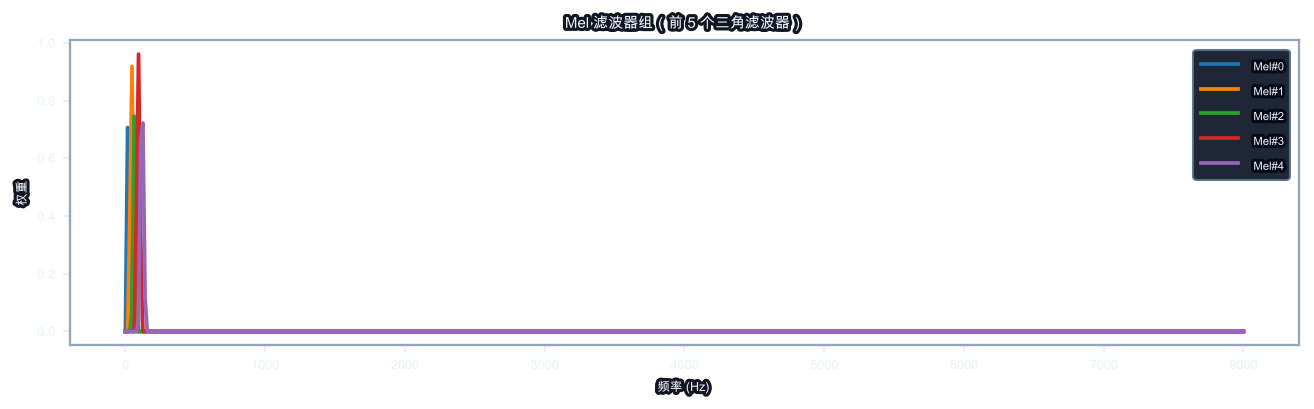

In [4]:
# 验证每一步的 shape
print(f"x        : {x.shape}")
print(f"STFT     : {S.shape}")
print(f"power    : {power.shape}")
print(f"fb       : {fb.shape}")
print(f"mel_enrg : {mel_energy.shape}")
print(f"log_mel  : {np.log(mel_energy + 1e-8).shape}")

# 可视化 mel 滤波器组前 5 个滤波器
freqs = np.fft.rfftfreq(1024, 1/sr)
fig, ax = plt.subplots(figsize=(9, 3))
for i in range(5):
    ax.plot(freqs, fb[i], label=f"Mel#{i}")
ax.set_xlabel("频率 (Hz)")
ax.set_ylabel("权重")
ax.set_title("Mel 滤波器组（前 5 个三角滤波器）")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 3. eps 与均值归一化

**eps = 1e-8**：唯一的数值保护。log(0) = -∞ 会让梯度炸掉，加 eps 把最小值钳在 `log(1e-8) ≈ -18.4`，物理上对应极弱的能量，不影响有效帧。

**计算 log(1e-8)**（用自然对数 ln）：

$$\ln(10^{-8}) = -8 \times \ln(10) = -8 \times 2.303 \approx -18.42$$

也就是说，即使 mel_energy 接近 0，加上 eps 后它会变成 1e-8，然后 log 把它压到约 -18.4 这个安全的下界。这个下界既远离 -∞（不会导致梯度爆炸），又足够小（不会让网络学到"0 能量也有信息"这样的假象）。

**均值归一化（CMVN）**：训练前通常对整段音频做：

```
log_mel_norm = (log_mel - log_mel.mean(axis=0)) / (log_mel.std(axis=0) + 1e-8)
```

`axis=0` 对每个 Mel bin 独立归一化，消除麦克风频率响应偏差，让模型在不同录音条件下更稳定。这里分母的 `1e-8` 也是防止某个 bin 的方差为 0 时除以零（虽然这种情况少见，但有数值保护总是好的）。

Month 2 分类器的预处理层会做这一步，但 `mel_spectrogram` 本身不包含它，保持功能单一。

归一化前 均值=-14.345  std=6.810
归一化后 均值=0.000  std=1.000


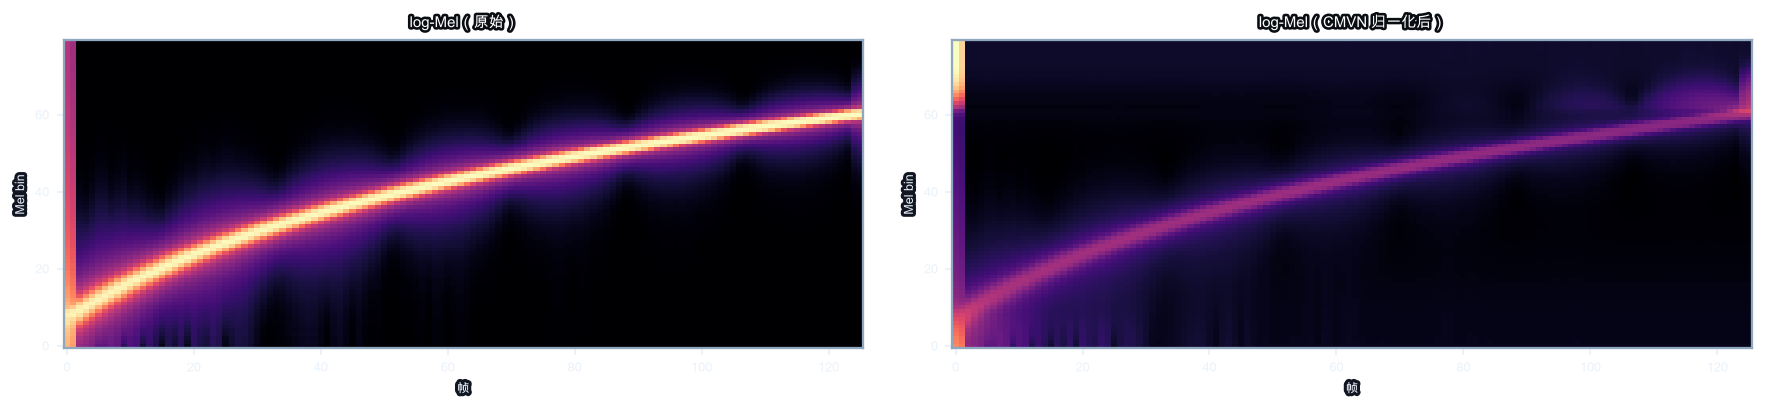

In [5]:
# 演示 CMVN 归一化效果
log_mel = np.log(mel_energy + 1e-8)
log_mel_norm = (log_mel - log_mel.mean(axis=0)) / (log_mel.std(axis=0) + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].imshow(log_mel.T, aspect="auto", origin="lower", cmap="magma")
axes[0].set_title("log-Mel（原始）")
axes[0].set_xlabel("帧"); axes[0].set_ylabel("Mel bin")

axes[1].imshow(log_mel_norm.T, aspect="auto", origin="lower", cmap="magma")
axes[1].set_title("log-Mel（CMVN 归一化后）")
axes[1].set_xlabel("帧"); axes[1].set_ylabel("Mel bin")
plt.tight_layout()
plt.show()

print(f"归一化前 均值={log_mel.mean():.3f}  std={log_mel.std():.3f}")
print(f"归一化后 均值={log_mel_norm.mean():.3f}  std={log_mel_norm.std():.3f}")

### 3.1 插曲：验收标准里的 `atol=1e-6` 是怎么来的？

*(琳达的问题：后面 4.1 节的验证代码用 `np.allclose(out, ref, atol=1e-6)` 判断你的实现对不对——这个 1e-6 是随手拍的，还是有讲究？)*

**先做一个类比。** 用计算器算 1/3，屏幕上显示 `0.3333333333`，但真正的 1/3 是无限循环小数——计算器只能存有限位数字，最后一位注定是"凑出来的"。计算机里的浮点数（float64）也是同样的道理：它只用 64 个 bit 存一个实数，能精确表示的数字是有限多个，落在两个"可表示数字"之间的结果，都要被舍入到最近的那一个。

**这个"舍入误差"到底有多小？** NumPy 里可以直接查到：

```python
np.finfo(np.float64).eps  # ≈ 2.22e-16
```

这个数字叫**机器精度**（machine epsilon）：两个相邻的、float64 能精确表示的数字之间的相对距离，大约是 2.22 × 10⁻¹⁶。也就是说，每做**一次**浮点运算（加、乘……），结果的相对误差大概就在这个量级——小到可以忽略。

**但这条流水线不是只做一次运算。** `log_mel_spectrogram` 要经过 STFT → 取模 → 平方 → 矩阵乘法 → log，一共 5 步，每一步都会引入一点新的舍入误差，误差会像滚雪球一样累积。更麻烦的是最后一步：`log` 函数对接近 0 的输入特别敏感——它的导数是 `1/x`，`x` 越小，一个很小的输入误差被放大得越厉害。举个具体的数：如果 `mel_energy` 里某个值恰好落在 `eps = 1e-8` 附近，哪怕这个值本身的相对误差只有 1e-13 这么小，经过 `log` 之后，绝对误差也可能被放大到 `1e-13 × (1/1e-8) = 1e-5` 这个量级——比 float64 机器精度大了 10 个数量级！

把这些因素叠加起来——5 步运算的累积误差，加上 `log` 在小值区间的放大效应——一个**完全正确**的实现，其输出和参考实现之间的差异，通常会落在 **1e-10 ~ 1e-6** 这个区间，而不是机器精度本身的 1e-16。`atol=1e-6` 选在这个区间的上沿，是为了给"计算路径不同、但数学上完全等价"的两种正确实现留出安全余量。

**那为什么不干脆放宽到 1e-4，更保险一点？** 因为容差还要能揪出**真正的 bug**。如果你漏了平方这一步（用了 `|S|` 而不是 `|S|²`），或者滤波器矩阵转置搞反了，误差通常是 `O(0.1) ~ O(10)` 这个量级——比 1e-6 大出好几个数量级，一眼就能被 `allclose` 揪出来。1e-6 卡在"能容忍正确实现的路径差异"和"能识破错误实现"这两者的中间地带。

**回到琳达的具体追问**："如果我用了稍微不同的数值顺序（比如 log 后再加常数 vs 加常数后再 log），精度会超过 1e-6 吗？" —— 这里要先把两件事分清楚：

1. `log(x) + c` 和 `log(x + c)`：这两个公式在数学上根本不是一回事（除非 c = 0），并不是"顺序不同"，而是**公式选错了**。它们的差异在 x 很小时会非常大，量级跟舍入误差完全不是一回事，会被 `atol=1e-6` 轻松抓出来——这不属于我们讨论的"数值误差"范畴，属于实现 bug。
2. 真正意义上的"运算顺序不同"，比如矩阵乘法是逐帧算完再拼起来，还是整体一次算完——这两者数学上严格等价，只是浮点运算的中间步骤（加法结合律在浮点数里其实不成立）不同，产生的差异才是我们说的"舍入误差"，量级大约在 1e-13 ~ 1e-9，远低于 1e-6 的容差。

下面用代码把这两种"误差"的量级摆在一起对比，你会看到它们相差了好几个数量级——这就是为什么 1e-6 既宽松又严格：宽松到能装下所有"殊途同归"的正确实现，严格到任何一个真实 bug 都无处遁形。

**再补一个参考点**：业界常见的音频库（librosa、torchaudio）在测试自己的 Mel 频谱实现时，同样普遍使用 1e-5 ~ 1e-6 这个数量级的容差，而不是逼近机器精度的 1e-12——原因和这里完全一样：FFT + log 的组合运算，天然需要给"计算路径不同但结果等价"的实现留出空间。

In [6]:
# 演示：两种"误差"的量级差了多少个数量级？

eps_machine = np.finfo(np.float64).eps
print(f"float64 机器精度 eps ≈ {eps_machine:.2e}\n")

# ── 场景 A：数学上完全等价，只是运算顺序不同（这才是"舍入误差"）──
# 整体一次算完 vs 逐帧算完再拼起来，结果理论上应该完全相同
mel_a = power @ fb.T
mel_b = np.stack([power[i] @ fb.T for i in range(power.shape[0])])
err_order = np.max(np.abs(mel_a - mel_b))
print(f"[运算顺序不同] power @ fb.T 整体算 vs 逐帧算 → 最大误差 = {err_order:.2e}")
print("  → 这才是真正的浮点舍入误差，远小于 atol=1e-6\n")

# ── 场景 B：公式选错了（不是舍入误差，是 bug）──
# 用几个接近 eps=1e-8 量级的"弱能量" bin 来演示——这正是 eps 保护要处理的场景
x_small = np.array([1e-10, 1e-9, 1e-8, 1e-7, 1e-6])
formula_correct = np.log(x_small + 1e-8)   # 正确公式：先加 eps 再 log
formula_wrong = np.log(x_small) + 1e-8     # 错误直觉：先 log 再加 eps
err_formula = np.max(np.abs(formula_correct - formula_wrong))
print(f"[公式选错]     log(x+eps) vs log(x)+eps        → 最大误差 = {err_formula:.2e}")
print("  → 这不是舍入误差，是数学上不同的两个公式，量级远超 1e-6\n")

print(f"两者相差 ≈ {err_formula / max(err_order, 1e-300):.1e} 倍——")
print("这就是为什么 atol=1e-6 能放行『顺序不同』，又能抓住『公式错误』。")

float64 机器精度 eps ≈ 2.22e-16

[运算顺序不同] power @ fb.T 整体算 vs 逐帧算 → 最大误差 = 4.37e-11
  → 这才是真正的浮点舍入误差，远小于 atol=1e-6

[公式选错]     log(x+eps) vs log(x)+eps        → 最大误差 = 4.62e+00
  → 这不是舍入误差，是数学上不同的两个公式，量级远超 1e-6

两者相差 ≈ 1.1e+11 倍——
这就是为什么 atol=1e-6 能放行『顺序不同』，又能抓住『公式错误』。


## 4. ✏️ 实现 `log_mel_spectrogram(x, sr, n_mels=80, win_len=1024, hop=256)`

**三步提示**：

1. **第一步：调用 STFT**
   ```python
   S = stft(x, n_fft=win_len, hop_length=hop)
   # S 是复数矩阵，shape (n_frames, win_len//2+1)
   ```

2. **第二步：计算功率谱**
   ```python
   magnitude = np.abs(S)      # 把复数变成幅度（实数）
   power = magnitude ** 2     # 平方
   # power 的 shape 是 (n_frames, win_len//2+1)
   ```

3. **第三步：获得 Mel 滤波器并应用**
   ```python
   fb = mel_filterbank(n_mels, win_len, sr)
   # fb 的 shape 是 (n_mels, win_len//2+1)
   mel_energy = power @ fb.T  # 矩阵乘法
   # mel_energy 的 shape 是 (n_frames, n_mels)
   ```

4. **第四步：log 压缩（加 eps 防止 log(0)）**
   ```python
   return np.log(mel_energy + 1e-8)
   # 返回 shape (n_frames, n_mels)
   ```

**卡住回**：L44（STFT 复习） / L46（Mel 滤波器复习）

**参考实现**：`solutions/L47_mel_implement_solutions.md`

## 4.1 关键函数的签名和调用方式

在实现 `log_mel_spectrogram` 前，你需要明确你依赖的两个函数。

### `stft(x, n_fft=..., hop_length=...)`

**导入**：
```python
from aurora.audio.stft import stft
```

**签名**：
```python
def stft(x, n_fft=1024, hop_length=256, window='hann'):
    """
    x        : 1-D float array，原始波形
    n_fft    : FFT 窗长，默认 1024
    hop_length : 帧间隔（样本点），默认 256
    window   : 窗函数名，默认 'hann'（汉宁窗）
    
    返回    : (n_frames, n_fft//2 + 1) 复数数组（STFT）
    """
```

**关键点**：
- **返回复数矩阵**。每个数字是 `a + b*j` 的形式，幅度为 `|a + b*j| = sqrt(a² + b²)`
- `n_fft` 就是窗长，也通常叫 `win_len`
- `hop_length` 是帧间隔，本课记作 `hop`

**例子**：
```python
S = stft(x, n_fft=1024, hop_length=256)  # S.shape = (某个n_frames, 513)
# 513 = 1024 // 2 + 1（FFT 的实频谱长度）

# 获得幅度（power spectrum 的前一步）
magnitude = np.abs(S)       # magnitude.shape = (n_frames, 513)，实数
power = magnitude ** 2      # power.shape = (n_frames, 513)，实数
```

### `mel_filterbank(n_mels, n_fft, sample_rate)`

**导入**：
```python
from aurora.audio.mel import mel_filterbank
```

**签名**：
```python
def mel_filterbank(n_mels, n_fft, sample_rate):
    """
    n_mels      : Mel 滤波器数量，通常 80
    n_fft       : FFT 窗长（必须和 STFT 的 n_fft 一致！）
    sample_rate : 采样率，通常 16000 Hz
    
    返回        : (n_mels, n_fft//2 + 1) 实数数组
                  每行是一个三角滤波器的权重向量
    """
```

**关键点**：
- **n_fft 必须和 stft 的 n_fft 保持一致**，否则维度对不上
- 返回的是实数矩阵，每行可以直接用来滤波
- 参数顺序是 `(n_mels, n_fft, sample_rate)`

**例子**：
```python
fb = mel_filterbank(80, 1024, 16000)  # fb.shape = (80, 513)
# 每一行是一个 Mel 滤波器，所有行加起来（不转置）大致覆盖整个频率轴

# 验证：可以看到滤波器的模样
import matplotlib.pyplot as plt
freqs = np.fft.rfftfreq(1024, 1/16000)
plt.plot(freqs, fb[40])  # 画出第 40 个滤波器
plt.xlabel('频率 (Hz)')
plt.ylabel('权重')
plt.show()
```

### 为什么 `n_fft//2 + 1`？

STFT 输出的只是**正频率**部分（负频率部分是正频率的镜像，实信号不需要）。对于 `n_fft=1024`：
- 完整的 FFT 输出有 1024 个复数
- 其中 1 个是 DC（0 Hz），512 个是正频率，512 个是负频率（镜像）
- 保留的是 0 Hz + 512 个正频率 = 513 = 1024//2 + 1

这也是为什么 Mel 滤波器组的第二维总是 `n_fft//2 + 1`。

In [7]:
# 注意：下方 TODO 使用 stft 与 mel_filterbank（stft 已在前文导入）
from aurora.audio.mel import mel_filterbank

def log_mel_spectrogram(x, sr, n_mels=80, win_len=1024, hop=256):
    """
    x       : 1-D numpy array, 原始波形
    sr      : 采样率（Hz）
    n_mels  : Mel 滤波器数量，默认 80
    win_len : FFT 窗长（= n_fft），默认 1024
    hop     : 帧移（samples），默认 256
    返回   : (n_frames, n_mels) float64 log-Mel 矩阵
    """
    # ✏️ TODO step 1: STFT → 复数矩阵 S，shape (n_frames, win_len//2+1)

    # ✏️ TODO step 2: power = |S|²，shape 同上

    # ✏️ TODO step 3: mel_filterbank → fb，shape (n_mels, win_len//2+1)

    # ✏️ TODO step 4: mel_energy = power @ fb.T，shape (n_frames, n_mels)

    # ✏️ TODO step 5: return np.log(mel_energy + 1e-8)
    raise NotImplementedError("TODO: 返回 log(mel_filterbank @ magnitude_spectrogram + 1e-8)")

In [ ]:
from aurora.audio.mel import mel_spectrogram

# 构造参考输出：aurora mel_spectrogram 不含 log，手动加 log+eps 作为参考
ref = np.log(mel_spectrogram(x, sr, n_fft=1024, hop_length=256, n_mels=80) + 1e-8)
out = log_mel_spectrogram(x, sr, n_mels=80, win_len=1024, hop=256)

assert out is not None, "函数返回了 None，请检查是否有 return 语句"
assert out.shape == ref.shape, f"shape 不匹配：{out.shape} vs {ref.shape}"
assert np.allclose(out, ref, atol=1e-6), (
    f"数值不匹配，最大误差 = {np.max(np.abs(out - ref)):.2e}"
)
print(f"✅ shape = {out.shape}")
print(f"✅ 最大误差 = {np.max(np.abs(out - ref)):.2e}（< 1e-6）")
print(f"✅ 值域 [{out.min():.2f}, {out.max():.2f}]")

## 5. 参数实验：n_mels = 40 / 80 / 128

**预期现象**：
- `n_mels=40`：频率分辨率粗，热力图垂直方向像素少，低频细节丢失，但计算快；Month 2 小模型可以用
- `n_mels=80`：平衡选择，业界标准（Whisper、wav2vec2 都用 80）
- `n_mels=128`：高频细节更多，对音乐/环境声分类有利，但特征维度增大，模型参数量随之增加

Month 2 实验时可对比三种设定下关键词识别的 val accuracy，通常 80 与 128 差距不大。

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, n_mels in zip(axes, [40, 80, 128]):
    try:
        feat = log_mel_spectrogram(x, sr, n_mels=n_mels, win_len=1024, hop=256)
    except (NotImplementedError, TypeError):
        feat = None
    if feat is None:  # stub 未完成（抛 NotImplementedError 或返回 None）时跳过
        ax.set_title(f"n_mels={n_mels}\n（请先完成 cell 10 的 TODO）")
        continue
    im = ax.imshow(feat.T, aspect="auto", origin="lower", cmap="magma")
    ax.set_title(f"n_mels = {n_mels}\nshape {feat.shape}")
    ax.set_xlabel("帧")
    ax.set_ylabel("Mel bin")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("log-Mel 频谱：n_mels 对比（chirp 200→4000 Hz，2 s）", y=1.02)
plt.tight_layout()
plt.show()

## 本课收束

本节实现了 `log_mel_spectrogram(x, sr, n_mels, win_len, hop)`，输出 `(n_frames, n_mels)` 的 float64 矩阵，并与 `aurora.audio.mel.mel_spectrogram` 对齐到 1e-6 精度。函数内部依赖 `aurora.audio.stft.stft` 和 `aurora.audio.mel.mel_filterbank`，所以这一步不是“再造一个近似版”，而是把整条前端链路真正拼稳。下一课：**L48** 时频图解析，用多组图把线性谱、Mel 谱和对数 Mel 谱的差别真正看出来。

## ✏️ 闭卷推导检查格 — Mel 滤波器归一化

**规则：关闭上方所有格，仅凭记忆完成以下推导。**

**题目**：三角滤波器 $H_m(k)$ 的定义为：

$$H_m(k) = \begin{cases}
\frac{k - f(m-1)}{f(m) - f(m-1)} & f(m-1) \le k < f(m) \\
\frac{f(m+1) - k}{f(m+1) - f(m)} & f(m) \le k \le f(m+1) \\
0 & \text{otherwise}
\end{cases}$$

**分段函数的几何意义**：

- `f(m-1), f(m), f(m+1)` 是三个频率点（单位：Hz 或 FFT bin index）
- 第一段（上升）：从 `f(m-1)` 到 `f(m)`，权重从 0 线性增到 1
  - 分子 `k - f(m-1)` 是当前位置到左端的距离
  - 分母 `f(m) - f(m-1)` 是总宽度，用来归一化使得最高点为 1
  - 例如：k 在中间点时，权重是 0.5
- 第二段（下降）：从 `f(m)` 到 `f(m+1)`，权重从 1 线性降到 0
  - 分子 `f(m+1) - k` 是当前位置到右端的距离
  - 分母 `f(m+1) - f(m)` 是总宽度
  - 例如：k 在中间点时，权重是 0.5
- 其他地方：权重为 0（这个滤波器不起作用）

**视觉理解**：三角滤波器看起来就像一座帐篷，`f(m)` 是顶点（高度 1），两侧是斜坡。

---

**推导题**：

1. 写出该滤波器面积（所有 $k$ 的求和）的解析表达式
   
   **提示**：面积 = $\sum_{k=f(m-1)}^{f(m+1)} H_m(k)$，可以分成两个三角形面积求和

2. Aurora 的实现是否归一化面积？若是，写出归一化后的表达式

（在此处写推导...）

In [ ]:
# 验证：滤波器矩阵每行之和（面积）是否符合预期
import numpy as np
from aurora.audio.mel import mel_filterbank

fb = mel_filterbank(n_mels=40, n_fft=1024, sample_rate=16000)  # shape (40, 513)
row_sums = fb.sum(axis=1)

# 推导答案：Aurora 采用 HTK 惯例——三角形峰值≈1，**不做**面积归一化。
# 因此滤波器越宽（越靠高频），行面积越大：低频窄三角面积小，高频宽三角面积大。
# 若需 Slaney 风格面积归一化，需手动将每行除以对应的 Hz 带宽。
assert row_sums.min() > 0, "存在全零行，滤波器构造有误"
assert row_sums[-1] > row_sums[0] * 5, "高频行面积应远大于低频行（HTK 不归一化面积）"
print(f"滤波器行面积：min={row_sums.min():.4f}（低频窄三角）→ max={row_sums.max():.4f}（高频宽三角）")
print(f"面积比 max/min = {row_sums.max()/row_sums.min():.1f}×")
print("✅ 结论：Aurora 不做面积归一化（HTK 峰值≈1 惯例），行面积随带宽增大")

In [ ]:
# ✏️ 本课自评
l47_review = {
    "pipeline_5steps":         None,  # 记住 STFT→power→@fb.T→log+ε 五步流程？True/False
    "log_mel_implemented":     None,  # log_mel_spectrogram 实现并通过 atol=1e-6？True/False
    "eps_role":                None,  # 理解 ε=1e-8 防 log(0)=-inf，最小值约-18？True/False
    "shape_flow":              None,  # 能手算 (T,)→(n_frames,n_bins)→(n_frames,n_mels) shape？True/False
    "whiteboard_passed":       None,  # 白板推导滤波器归一化闭卷通过？True/False
}

unfilled = [k for k, v in l47_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l47_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L47 全部通关！进入 L48：时频图解（可视化课）')

---

→ **下一课**　[L48 · 时频图解](L48_visual_stft.ipynb)

> 下节课将学习 **时频图解**：线性谱 / Mel 谱 / 对数 Mel 谱三者视觉对比。